In [1]:
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("divorce_data.csv", sep=";")
df.head()

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q46,Q47,Q48,Q49,Q50,Q51,Q52,Q53,Q54,Divorce
0,2,2,4,1,0,0,0,0,0,0,...,2,1,3,3,3,2,3,2,1,1
1,4,4,4,4,4,0,0,4,4,4,...,2,2,3,4,4,4,4,2,2,1
2,2,2,2,2,1,3,2,1,1,2,...,3,2,3,1,1,1,2,2,2,1
3,3,2,3,2,3,3,3,3,3,3,...,2,2,3,3,3,3,2,2,2,1
4,2,2,1,1,1,1,0,0,0,0,...,2,1,2,3,2,2,2,1,0,1


In [4]:
df.shape

(170, 55)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 55 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Q1       170 non-null    int64
 1   Q2       170 non-null    int64
 2   Q3       170 non-null    int64
 3   Q4       170 non-null    int64
 4   Q5       170 non-null    int64
 5   Q6       170 non-null    int64
 6   Q7       170 non-null    int64
 7   Q8       170 non-null    int64
 8   Q9       170 non-null    int64
 9   Q10      170 non-null    int64
 10  Q11      170 non-null    int64
 11  Q12      170 non-null    int64
 12  Q13      170 non-null    int64
 13  Q14      170 non-null    int64
 14  Q15      170 non-null    int64
 15  Q16      170 non-null    int64
 16  Q17      170 non-null    int64
 17  Q18      170 non-null    int64
 18  Q19      170 non-null    int64
 19  Q20      170 non-null    int64
 20  Q21      170 non-null    int64
 21  Q22      170 non-null    int64
 22  Q23      170 non-null    int64
 23  Q

In [6]:
df.isnull().sum()

Q1         0
Q2         0
Q3         0
Q4         0
Q5         0
Q6         0
Q7         0
Q8         0
Q9         0
Q10        0
Q11        0
Q12        0
Q13        0
Q14        0
Q15        0
Q16        0
Q17        0
Q18        0
Q19        0
Q20        0
Q21        0
Q22        0
Q23        0
Q24        0
Q25        0
Q26        0
Q27        0
Q28        0
Q29        0
Q30        0
Q31        0
Q32        0
Q33        0
Q34        0
Q35        0
Q36        0
Q37        0
Q38        0
Q39        0
Q40        0
Q41        0
Q42        0
Q43        0
Q44        0
Q45        0
Q46        0
Q47        0
Q48        0
Q49        0
Q50        0
Q51        0
Q52        0
Q53        0
Q54        0
Divorce    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(20)

In [8]:
df["Divorce"].value_counts()

Divorce
0    86
1    84
Name: count, dtype: int64

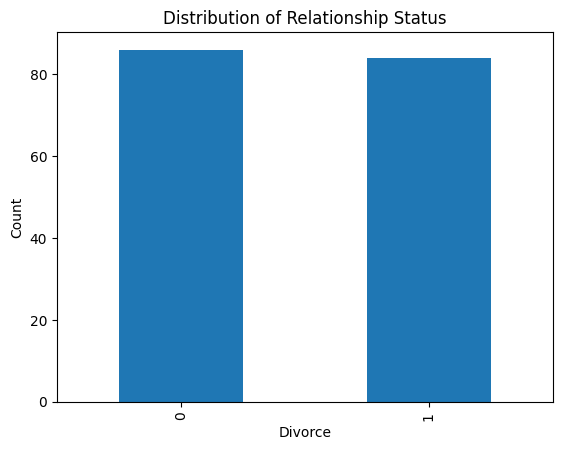

In [9]:
df["Divorce"].value_counts().plot(kind="bar")

plt.title("Distribution of Relationship Status")
plt.xlabel("Divorce")
plt.ylabel("Count")
plt.show()

In [10]:
corr_with_target = df.corr()["Divorce"].sort_values(ascending=False)
corr_with_target

Divorce    1.000000
Q40        0.938684
Q17        0.929346
Q19        0.928627
Q18        0.923208
Q11        0.918386
Q9         0.912368
Q20        0.907008
Q15        0.901220
Q39        0.896180
Q41        0.894356
Q5         0.893180
Q29        0.892954
Q36        0.886497
Q16        0.886260
Q38        0.883311
Q30        0.874531
Q26        0.872868
Q27        0.869788
Q8         0.869569
Q12        0.868983
Q21        0.864519
Q14        0.864316
Q37        0.863597
Q35        0.862624
Q33        0.861328
Q1         0.861324
Q25        0.857052
Q44        0.847336
Q28        0.846606
Q13        0.844743
Q24        0.839392
Q23        0.837504
Q34        0.835167
Q10        0.834897
Q32        0.829056
Q22        0.825938
Q2         0.820774
Q4         0.819583
Q54        0.806765
Q3         0.806709
Q31        0.792607
Q50        0.755248
Q49        0.740704
Q42        0.739629
Q53        0.711176
Q51        0.692681
Q47        0.656409
Q52        0.651478
Q48        0.619830


In [11]:
top_features = corr_with_target.abs().sort_values(ascending=False).head(11)
top_features


Divorce    1.000000
Q40        0.938684
Q17        0.929346
Q19        0.928627
Q18        0.923208
Q11        0.918386
Q9         0.912368
Q20        0.907008
Q15        0.901220
Q39        0.896180
Q41        0.894356
Name: Divorce, dtype: float64

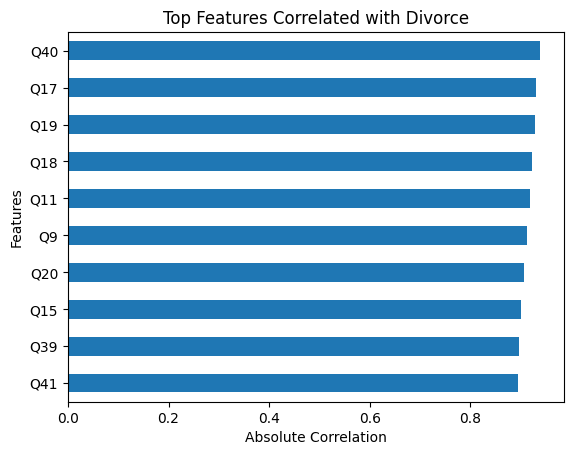

In [12]:
top_features.drop("Divorce").sort_values().plot(kind="barh")

plt.title("Top Features Correlated with Divorce")
plt.xlabel("Absolute Correlation")
plt.ylabel("Features")
plt.show()

In [13]:
ref = pd.read_csv("reference.tsv", sep="|")
ref.head()

,atribute_id,description
0,1,If one of us apologizes when our discussion de...
1,2,"I know we can ignore our differences, even if ..."
2,3,"When we need it, we can take our discussions w..."
3,4,"When I discuss with my spouse, to contact him ..."
4,5,The time I spent with my wife is special for us.


In [14]:
ref.columns

Index(['atribute_id', 'description'], dtype='str')

In [15]:
top_feature_names = top_features.drop("Divorce").index
top_feature_names

Index(['Q40', 'Q17', 'Q19', 'Q18', 'Q11', 'Q9', 'Q20', 'Q15', 'Q39', 'Q41'], dtype='str')

In [17]:
ref = pd.read_csv("reference.tsv", sep="|")

top_feature_names = top_features.drop("Divorce").index

ref["question_id"] = "Q" + ref["atribute_id"].astype(str)

top_feature_descriptions = ref[ref["question_id"].isin(top_feature_names)]

top_feature_descriptions

,atribute_id,description,question_id
8,9,I enjoy traveling with my wife.,Q9
10,11,"I think that one day in the future, when I loo...",Q11
14,15,Our dreams with my spouse are similar and harm...,Q15
16,17,We share the same views about being happy in o...,Q17
17,18,My spouse and I have similar ideas about how m...,Q18
18,19,My spouse and I have similar ideas about how r...,Q19
19,20,My spouse and I have similar values in trust.,Q20
38,39,Our discussions often occur suddenly.,Q39
39,40,We're just starting a discussion before I know...,Q40
40,41,"When I talk to my spouse about something, my c...",Q41


In [18]:
top_feature_descriptions = top_feature_descriptions.set_index("question_id").loc[top_feature_names]

top_feature_descriptions

,atribute_id,description
Q40,40,We're just starting a discussion before I know...
Q17,17,We share the same views about being happy in o...
Q19,19,My spouse and I have similar ideas about how r...
Q18,18,My spouse and I have similar ideas about how m...
Q11,11,"I think that one day in the future, when I loo..."
Q9,9,I enjoy traveling with my wife.
Q20,20,My spouse and I have similar values in trust.
Q15,15,Our dreams with my spouse are similar and harm...
Q39,39,Our discussions often occur suddenly.
Q41,41,"When I talk to my spouse about something, my c..."


In [19]:
important_features = top_features.drop("Divorce").index

group_mean = df.groupby("Divorce")[important_features].mean().T
group_mean


Divorce,0,1
Q40,0.209302,3.571429
Q17,0.174419,3.166667
Q19,0.139535,3.178571
Q18,0.093023,2.976190
Q11,0.197674,3.214286
Q9,0.058140,2.892857
Q20,0.069767,2.880952
Q15,0.232558,2.940476
Q39,0.569767,3.642857
Q41,0.476744,3.547619


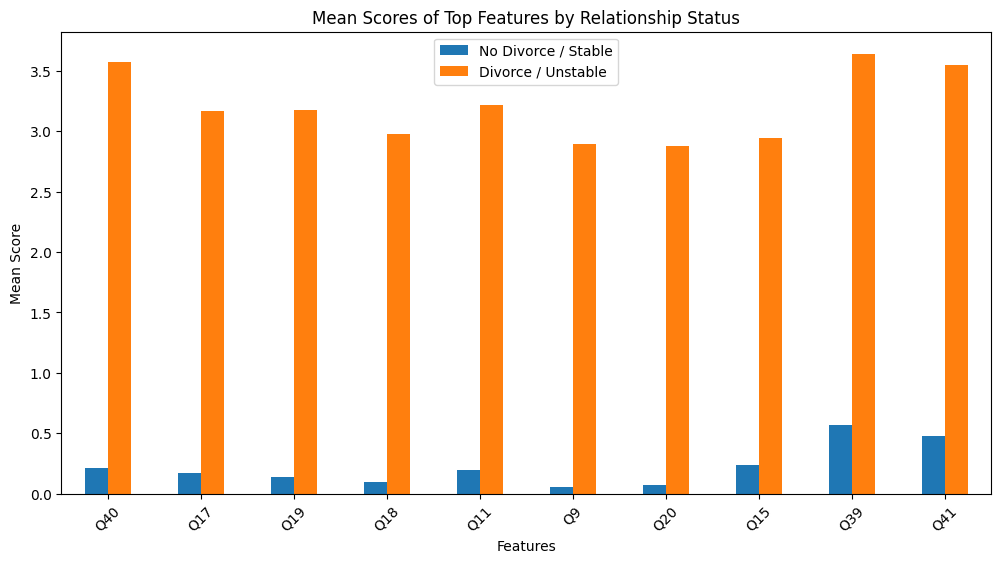

In [20]:
group_mean.plot(kind="bar", figsize=(12, 6))

plt.title("Mean Scores of Top Features by Relationship Status")
plt.xlabel("Features")
plt.ylabel("Mean Score")
plt.xticks(rotation=45)
plt.legend(["No Divorce / Stable", "Divorce / Unstable"])
plt.show()

In [22]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.3 MB 11.5 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 20.1 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 18.5 MB/s  0:00:00

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [sc


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [24]:
X = df.drop("Divorce", axis=1)
y = df["Divorce"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        20

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34

[[14  0]
 [ 0 20]]


In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))

Accuracy: 0.9705882352941176
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       1.00      0.95      0.97        20

    accuracy                           0.97        34
   macro avg       0.97      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34

[[14  0]
 [ 1 19]]
